# Exploratory Data Analysis: US Traffic Accident Severity

**Project:** Predicting Traffic Accident Severity  
**Authors:** Osvaldo Rivera, Nitin Nellisserry  

In [1]:
# This section we will begin to explore, clean, and prepare the US Accidents dataset for modeling 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("datasets/US_Accidents_March23.csv")
df = df.sample(n=300000, random_state=42)
df.head()


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
7133276,A-7182628,Source1,1,2020-04-17 09:29:30,2020-04-17 10:29:30,26.706900,-80.119360,26.706900,-80.119360,0.000,At Haverhill Rd - Earlier accident.,N Haverhill Rd,West Palm Beach,Palm Beach,FL,33417-4638,US,US/Eastern,KPBI,2020-04-17 09:24:00,78.0,78.0,81.0,30.13,10.0,ESE,13.0,0.01,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day
5363845,A-5404588,Source1,2,2022-04-21 10:01:00.000000000,2022-04-21 11:44:08.000000000,38.781024,-121.265820,38.780377,-121.265815,0.045,Incident on STANFORD RANCH RD near HOUSE 6750 ...,Stanford Ranch Rd,Roseville,Placer,CA,95678-1907,US,US/Pacific,KMCC,2022-04-21 09:55:00,55.0,55.0,88.0,29.83,10.0,SSE,9.0,0.00,Mostly Cloudy,False,False,True,False,False,False,False,False,False,True,False,False,False,Day,Day,Day,Day
155993,A-156000,Source3,3,2016-08-12 16:45:00,2016-08-12 17:15:00,33.985249,-84.269348,NaN,NaN,0.000,Accident on GA-140 Holcomb Bridge Rd Westbound...,Barnwell Rd,Alpharetta,Fulton,GA,30022,US,US/Eastern,KPDK,2016-08-12 16:53:00,91.0,NaN,47.0,29.91,10.0,South,10.4,NaN,Partly Cloudy,False,False,True,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
1861414,A-1871277,Source2,3,2019-09-20 15:22:16,2019-09-20 15:56:00,47.118706,-122.556908,NaN,NaN,0.000,Left lane blocked due to accident on I-5 North...,I-5 S,Tacoma,Pierce,WA,98433,US,US/Pacific,KGRF,2019-09-20 14:58:00,67.0,67.0,84.0,29.78,10.0,WNW,3.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
2021359,A-2031222,Source2,2,2019-06-03 16:55:43,2019-06-03 18:12:09,33.451355,-111.890343,NaN,NaN,0.000,Right lane closed due to accident on AZ-101-LO...,E McKellips Rd,Scottsdale,Maricopa,AZ,85256,US,US/Mountain,KFFZ,2019-06-03 16:51:00,95.0,95.0,16.0,28.53,10.0,WSW,6.0,0.00,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day


In [2]:
display(df.head())
print(df.shape)
df.info()

# Checking for missing values
df.isnull().mean().sort_values(ascending=False)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
7133276,A-7182628,Source1,1,2020-04-17 09:29:30,2020-04-17 10:29:30,26.706900,-80.119360,26.706900,-80.119360,0.000,At Haverhill Rd - Earlier accident.,N Haverhill Rd,West Palm Beach,Palm Beach,FL,33417-4638,US,US/Eastern,KPBI,2020-04-17 09:24:00,78.0,78.0,81.0,30.13,10.0,ESE,13.0,0.01,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day
5363845,A-5404588,Source1,2,2022-04-21 10:01:00.000000000,2022-04-21 11:44:08.000000000,38.781024,-121.265820,38.780377,-121.265815,0.045,Incident on STANFORD RANCH RD near HOUSE 6750 ...,Stanford Ranch Rd,Roseville,Placer,CA,95678-1907,US,US/Pacific,KMCC,2022-04-21 09:55:00,55.0,55.0,88.0,29.83,10.0,SSE,9.0,0.00,Mostly Cloudy,False,False,True,False,False,False,False,False,False,True,False,False,False,Day,Day,Day,Day
155993,A-156000,Source3,3,2016-08-12 16:45:00,2016-08-12 17:15:00,33.985249,-84.269348,NaN,NaN,0.000,Accident on GA-140 Holcomb Bridge Rd Westbound...,Barnwell Rd,Alpharetta,Fulton,GA,30022,US,US/Eastern,KPDK,2016-08-12 16:53:00,91.0,NaN,47.0,29.91,10.0,South,10.4,NaN,Partly Cloudy,False,False,True,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
1861414,A-1871277,Source2,3,2019-09-20 15:22:16,2019-09-20 15:56:00,47.118706,-122.556908,NaN,NaN,0.000,Left lane blocked due to accident on I-5 North...,I-5 S,Tacoma,Pierce,WA,98433,US,US/Pacific,KGRF,2019-09-20 14:58:00,67.0,67.0,84.0,29.78,10.0,WNW,3.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
2021359,A-2031222,Source2,2,2019-06-03 16:55:43,2019-06-03 18:12:09,33.451355,-111.890343,NaN,NaN,0.000,Right lane closed due to accident on AZ-101-LO...,E McKellips Rd,Scottsdale,Maricopa,AZ,85256,US,US/Mountain,KFFZ,2019-06-03 16:51:00,95.0,95.0,16.0,28.53,10.0,WSW,6.0,0.00,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day


(300000, 46)
<class 'pandas.core.frame.DataFrame'>
Index: 300000 entries, 7133276 to 6130162
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     300000 non-null  object 
 1   Source                 300000 non-null  object 
 2   Severity               300000 non-null  int64  
 3   Start_Time             300000 non-null  object 
 4   End_Time               300000 non-null  object 
 5   Start_Lat              300000 non-null  float64
 6   Start_Lng              300000 non-null  float64
 7   End_Lat                167565 non-null  float64
 8   End_Lng                167565 non-null  float64
 9   Distance(mi)           300000 non-null  float64
 10  Description            299999 non-null  object 
 11  Street                 299549 non-null  object 
 12  City                   299992 non-null  object 
 13  County                 300000 non-null  object 
 14  State                

End_Lng                  0.441450
End_Lat                  0.441450
Precipitation(in)        0.285513
Wind_Chill(F)            0.259103
Wind_Speed(mph)          0.074203
Visibility(mi)           0.022660
Wind_Direction           0.022637
Humidity(%)              0.022407
Weather_Condition        0.022150
Temperature(F)           0.021023
Pressure(in)             0.017987
Weather_Timestamp        0.015420
Sunrise_Sunset           0.003040
Civil_Twilight           0.003040
Astronomical_Twilight    0.003040
Nautical_Twilight        0.003040
Airport_Code             0.002893
Street                   0.001503
Timezone                 0.000963
Zipcode                  0.000207
City                     0.000027
Description              0.000003
ID                       0.000000
Distance(mi)             0.000000
Start_Lng                0.000000
Source                   0.000000
Severity                 0.000000
Start_Time               0.000000
End_Time                 0.000000
Start_Lat     

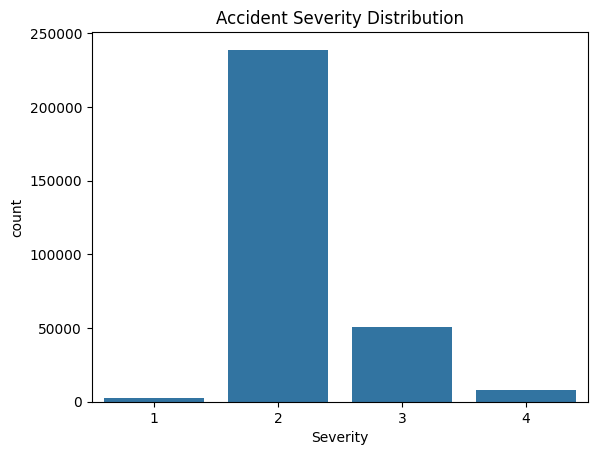

In [ ]:
# Target Variable: Severity Distribution and plotting
df["Severity"].value_counts(normalize=True)

sns.countplot(x="Severity", data=df)
plt.title("Accident Severity Distribution")
plt.show()

In [4]:
# Select Relevant Columns
selected_cols = [
    "Severity", "Start_Time", "Temperature(F)", "Humidity(%)",
    "Visibility(mi)", "Weather_Condition", "Precipitation(in)",
    "Wind_Speed(mph)", "Traffic_Signal", "Junction", "Crossing",
    "State"
]

df = df[selected_cols].copy()
print("After column selection:", df.shape)
df.head()

After column selection: (300000, 12)


,Severity,Start_Time,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,Precipitation(in),Wind_Speed(mph),Traffic_Signal,Junction,Crossing,State
7133276,1,2020-04-17 09:29:30,78.0,81.0,10.0,Mostly Cloudy,0.01,13.0,True,False,False,FL
5363845,2,2022-04-21 10:01:00.000000000,55.0,88.0,10.0,Mostly Cloudy,0.00,9.0,False,False,True,CA
155993,3,2016-08-12 16:45:00,91.0,47.0,10.0,Partly Cloudy,NaN,10.4,False,False,True,GA
1861414,3,2019-09-20 15:22:16,67.0,84.0,10.0,Cloudy,0.00,3.0,False,False,False,WA
2021359,2,2019-06-03 16:55:43,95.0,16.0,10.0,Fair,0.00,6.0,False,False,False,AZ


In [ ]:
# Feature Engineering
# converting time -> hour, day, weekday

df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="mixed", errors="coerce")

# Drop rows where Start_Time failed
before = len(df)
df = df.dropna(subset=["Start_Time"]).copy()
after = len(df)
print(f"Dropped {before - after} rows due to invalid Start_Time ({(before-after)/before:.3%})")

# Time-based features
df["Hour"] = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek
df["Is_Weekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

df.head()

Dropped 0 rows due to invalid Start_Time (0.000%)


,Severity,Start_Time,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,Precipitation(in),Wind_Speed(mph),Traffic_Signal,Junction,Crossing,State,Hour,DayOfWeek,Is_Weekend
7133276,1,2020-04-17 09:29:30,78.0,81.0,10.0,Mostly Cloudy,0.01,13.0,True,False,False,FL,9,4,0
5363845,2,2022-04-21 10:01:00,55.0,88.0,10.0,Mostly Cloudy,0.00,9.0,False,False,True,CA,10,3,0
155993,3,2016-08-12 16:45:00,91.0,47.0,10.0,Partly Cloudy,NaN,10.4,False,False,True,GA,16,4,0
1861414,3,2019-09-20 15:22:16,67.0,84.0,10.0,Cloudy,0.00,3.0,False,False,False,WA,15,4,0
2021359,2,2019-06-03 16:55:43,95.0,16.0,10.0,Fair,0.00,6.0,False,False,False,AZ,16,0,0


High_Severity
0    0.80458
1    0.19542
Name: proportion, dtype: float64


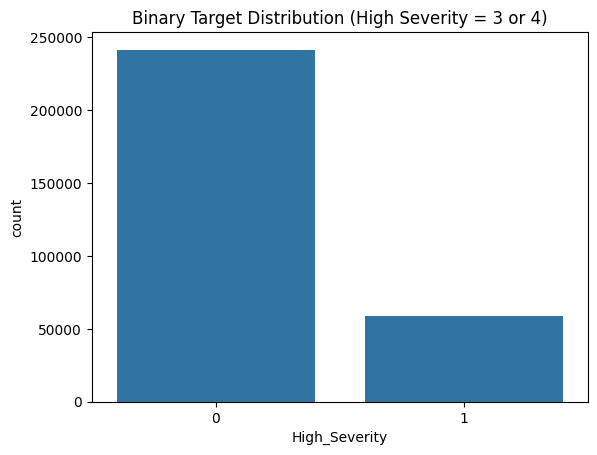

High severity rate: 0.19542
Severity
1    0.008643
2    0.795937
3    0.168667
4    0.026753
Name: proportion, dtype: float64


In [6]:
# Create Binary Target (Low Vs HIGH Severity)
df["High_Severity"] = (df["Severity"] >= 3).astype(int)
print(df["High_Severity"].value_counts(normalize=True))

sns.countplot(x="High_Severity", data=df)
plt.title("Binary Target Distribution (High Severity = 3 or 4)")
plt.show()

print("High severity rate:", df["High_Severity"].mean())
print(df["Severity"].value_counts(normalize=True).sort_index())

In [7]:
# Handle missing Values
# Numeric: median or 0 when appropriate
df["Temperature(F)"] = df["Temperature(F)"].fillna(df["Temperature(F)"].median())
df["Humidity(%)"] = df["Humidity(%)"].fillna(df["Humidity(%)"].median())
df["Visibility(mi)"] = df["Visibility(mi)"].fillna(df["Visibility(mi)"].median())

# Precipitation: many missing entries can reasonably be treated as 0 (no reported precip)
df["Precipitation(in)"] = df["Precipitation(in)"].fillna(0)

df["Wind_Speed(mph)"] = df["Wind_Speed(mph)"].fillna(df["Wind_Speed(mph)"].median())

# Categorical
df["Weather_Condition"] = df["Weather_Condition"].fillna("Unknown")

# Sanity check
df.isnull().mean().sort_values(ascending=False).head(10)

Severity             0.0
Start_Time           0.0
Temperature(F)       0.0
Humidity(%)          0.0
Visibility(mi)       0.0
Weather_Condition    0.0
Precipitation(in)    0.0
Wind_Speed(mph)      0.0
Traffic_Signal       0.0
Junction             0.0
dtype: float64

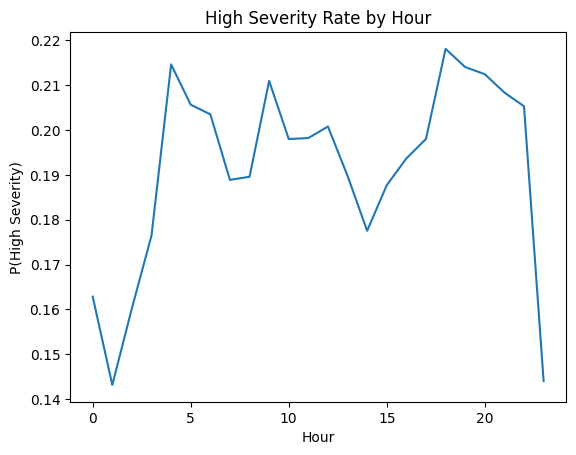

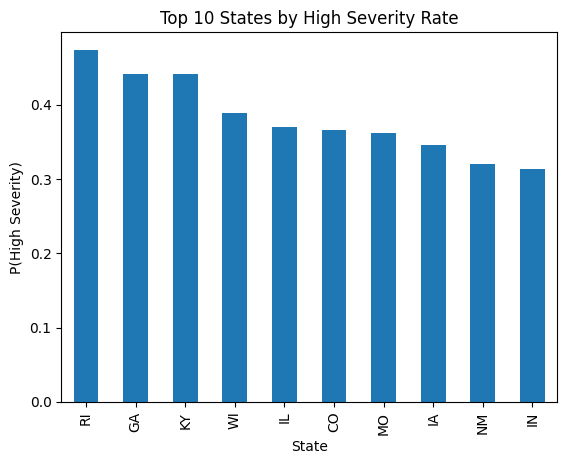

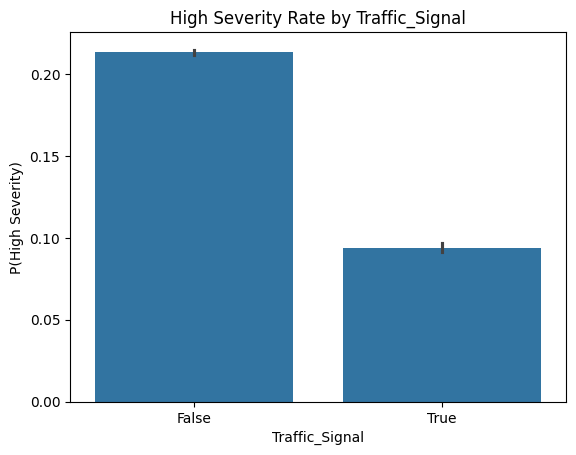

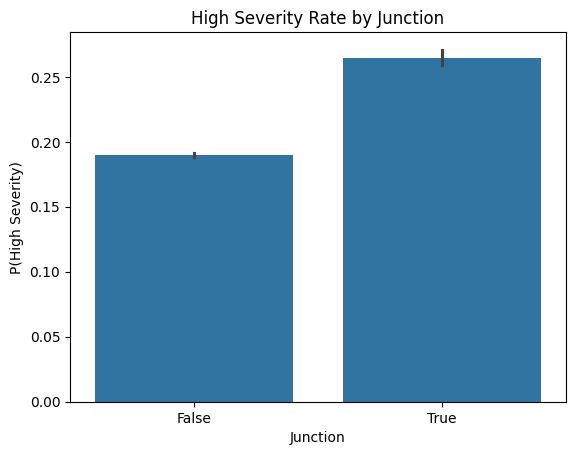

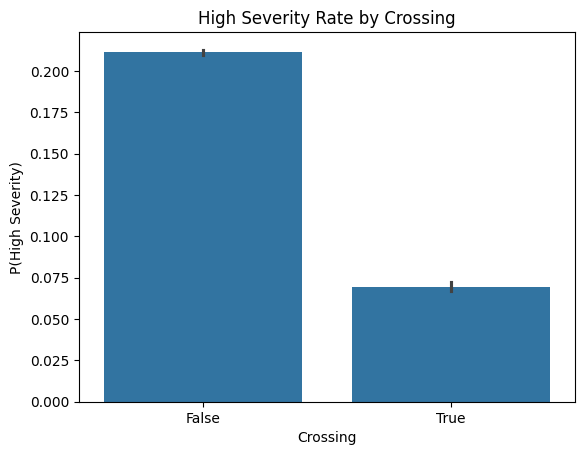

In [8]:
# EDA Visuals
# A) High severity rate by hour
hour_rate = df.groupby("Hour")["High_Severity"].mean()
hour_rate.plot(kind="line")
plt.title("High Severity Rate by Hour")
plt.ylabel("P(High Severity)")
plt.show()

# B) Severity rate by state (top 10)
state_rate = df.groupby("State")["High_Severity"].mean().sort_values(ascending=False).head(10)
state_rate.plot(kind="bar")
plt.title("Top 10 States by High Severity Rate")
plt.ylabel("P(High Severity)")
plt.show()

# C) Infrastructure flags vs severity
for col in ["Traffic_Signal", "Junction", "Crossing"]:
    sns.barplot(x=col, y="High_Severity", data=df)
    plt.title(f"High Severity Rate by {col}")
    plt.ylabel("P(High Severity)")
    plt.show()

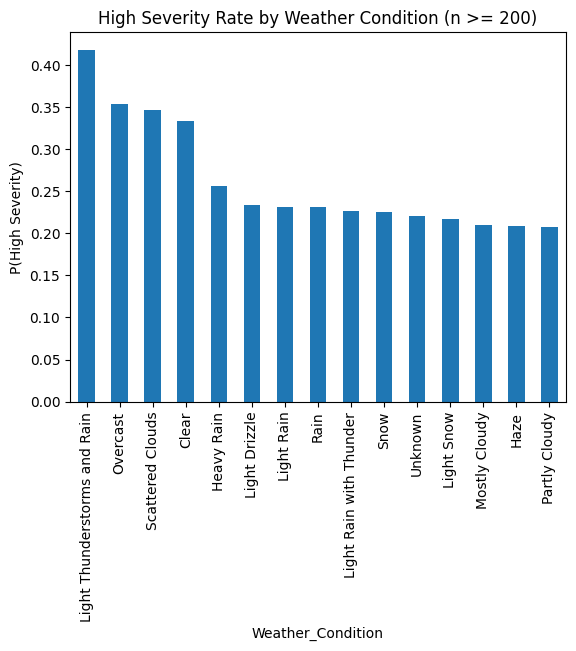

In [9]:
# Weather vs Severity
weather_stats = (
    df.groupby("Weather_Condition")["High_Severity"]
      .agg(rate="mean", n="size")
      .sort_values("rate", ascending=False)
)

# Only show categories with enough samples
weather_stats_filtered = weather_stats[weather_stats["n"] >= 200].head(15)
weather_stats_filtered

weather_stats_filtered["rate"].sort_values(ascending=False).plot(kind="bar")
plt.title("High Severity Rate by Weather Condition (n >= 200)")
plt.ylabel("P(High Severity)")
plt.show()

In [10]:
# One Hot Encode Categorical Features
df_model = df.drop(columns=["Start_Time"])  # drop raw datetime, keep engineered time features
df_model = pd.get_dummies(df_model, columns=["Weather_Condition", "State"], drop_first=True)

print("Model-ready shape:", df_model.shape)
df_model.head()

Model-ready shape: (300000, 156)


,Severity,Temperature(F),Humidity(%),Visibility(mi),Precipitation(in),Wind_Speed(mph),Traffic_Signal,Junction,Crossing,Hour,DayOfWeek,Is_Weekend,High_Severity,Weather_Condition_Blowing Dust / Windy,Weather_Condition_Blowing Snow,Weather_Condition_Blowing Snow / Windy,Weather_Condition_Clear,Weather_Condition_Cloudy,Weather_Condition_Cloudy / Windy,Weather_Condition_Drizzle,Weather_Condition_Drizzle / Windy,Weather_Condition_Drizzle and Fog,Weather_Condition_Fair,Weather_Condition_Fair / Windy,Weather_Condition_Fog,Weather_Condition_Fog / Windy,Weather_Condition_Freezing Drizzle,Weather_Condition_Freezing Rain,Weather_Condition_Freezing Rain / Windy,Weather_Condition_Funnel Cloud,Weather_Condition_Hail,Weather_Condition_Haze,Weather_Condition_Haze / Windy,Weather_Condition_Heavy Drizzle,Weather_Condition_Heavy Freezing Drizzle,Weather_Condition_Heavy Rain,Weather_Condition_Heavy Rain / Windy,Weather_Condition_Heavy Sleet,Weather_Condition_Heavy Snow,Weather_Condition_Heavy Snow / Windy,Weather_Condition_Heavy T-Storm,Weather_Condition_Heavy T-Storm / Windy,Weather_Condition_Heavy Thunderstorms and Rain,Weather_Condition_Ice Pellets,Weather_Condition_Light Drizzle,Weather_Condition_Light Drizzle / Windy,Weather_Condition_Light Freezing Drizzle,Weather_Condition_Light Freezing Fog,Weather_Condition_Light Freezing Rain,Weather_Condition_Light Freezing Rain / Windy,Weather_Condition_Light Ice Pellets,Weather_Condition_Light Rain,Weather_Condition_Light Rain / Windy,Weather_Condition_Light Rain Shower,Weather_Condition_Light Rain Showers,Weather_Condition_Light Rain with Thunder,Weather_Condition_Light Sleet,Weather_Condition_Light Sleet / Windy,Weather_Condition_Light Snow,Weather_Condition_Light Snow / Windy,Weather_Condition_Light Snow Grains,Weather_Condition_Light Snow and Sleet,Weather_Condition_Light Snow and Sleet / Windy,Weather_Condition_Light Snow with Thunder,Weather_Condition_Light Thunderstorms and Rain,Weather_Condition_Mist,Weather_Condition_Mostly Cloudy,Weather_Condition_Mostly Cloudy / Windy,Weather_Condition_N/A Precipitation,Weather_Condition_Overcast,Weather_Condition_Partial Fog,Weather_Condition_Partly Cloudy,Weather_Condition_Partly Cloudy / Windy,Weather_Condition_Patches of Fog,Weather_Condition_Rain,Weather_Condition_Rain / Windy,Weather_Condition_Rain Shower,Weather_Condition_Rain Showers,Weather_Condition_Rain and Sleet,Weather_Condition_Sand / Dust Whirlwinds,Weather_Condition_Scattered Clouds,Weather_Condition_Shallow Fog,Weather_Condition_Shallow Fog / Windy,Weather_Condition_Showers in the Vicinity,Weather_Condition_Sleet,Weather_Condition_Small Hail,Weather_Condition_Smoke,Weather_Condition_Smoke / Windy,Weather_Condition_Snow,Weather_Condition_Snow / Windy,Weather_Condition_Snow and Sleet,Weather_Condition_Snow and Sleet / Windy,Weather_Condition_Snow and Thunder,Weather_Condition_Squalls,Weather_Condition_Squalls / Windy,Weather_Condition_T-Storm,Weather_Condition_T-Storm / Windy,Weather_Condition_Thunder,Weather_Condition_Thunder / Windy,Weather_Condition_Thunder in the Vicinity,Weather_Condition_Thunderstorm,Weather_Condition_Thunderstorms and Rain,Weather_Condition_Thunderstorms and Snow,Weather_Condition_Tornado,Weather_Condition_Unknown,Weather_Condition_Widespread Dust,Weather_Condition_Wintry Mix,Weather_Condition_Wintry Mix / Windy,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
7133276,1,78.0,81.0,10.0,0.01,13.0,True,False,False,9,4,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [11]:
# Save cleaned dataset
df_model.to_csv("datasets/cleaned_accidents.csv", index=False)